# **Student Depression Prediction Model**

## **Introduction**

**Mental Health** is increasingly becoming a widespread concern among students of this generation as the pressure of excelling academically, socially, professionally, and even personally intensify with competition. Many students put more attention and focus into their academics and extracurriculars that they neglect their mental health, sometimes up until their symptoms reach a serious level. Some students are also in a situation where resources and help are minimal, and they do not have a person that they can talk to about these issues. If you or anyone you know is struggling with mental health issues, please remember that you are not alone and please reach out for help:

- **Emergency Services**: Please dial **911** if you believe that you or someone you know may be a danger to themselves or to others.

- **US National Hotline**: Please dial **(800) 273-8255** if you would like immediate help or counseling. This can also be dialed for non-emergency cases that can feel intense such as panic attacks, anxiety attacks, etc.

- **Crisis Text Line**: Please text **HOME** to **741741** for free, 24/7 crisis counseling.

- **Suicide & Crisis Lifeline**: Please dial **988** for a confidential, free, 24/7 counseling through emotional distress or suicidal crisis.

*REMEMBER: YOU ARE IMPORTANT, YOU ARE NOT ALONE, AND THERE IS ALWAYS A SOLUTION TO ANY ISSUE WHETHER IT'S PHYSICAL, EMOTIONAL, OR MENTAL. ALL YOU NEED TO DO IS ASK FOR HELP.*

## **Dataset Information**

Now, onto the project itself, the <a href="https://www.kaggle.com/datasets/hopesb/student-depression-dataset">**Student Depression Dataset**</a> contains information regarding 27,901 students across India about their academic, professional, and personal circumstances and habits. We will be using a subset of the features available for each student to train a model into predicting how likely a student is to be diagnosed with depression. We will first use **Principal Component Analysis (PCA)** to try and reduce the dimensionality of the features before passing them into a **Neural Network** that will output the probability of the student being diagnosed with depression and the probability of the student not being diagnosed with depression. To take the model's prediction, we must simply take the class with the higher probability of the two. Therefore, this is a **Binary Classification Problem** as students will be predicted to either be diagnosed with depression, or not be diagnosed with depression. We will be attempting to answer the following question through this project:

- **How accurately can we predict that a student is undergoing depression based on the student's academic, professional, and personal cicumstances and habits?**

### Importing Packages

Let us start by importing the necessary packages for our project.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

### Selecting the Features

Let us visualize the dataset in its initial form before taking our feature subset.

In [2]:
depression_data = pd.read_csv("Student_Depression_Dataset.csv")
depression_data.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


From all of the features in the dataset, we do not want the model to consider a student's gender, age, city, profession, and academic degree when predicting their likelihood of depression, so we will **NOT** be reading in the following features: 

- `Gender`: The student's gender.
- `Age`: The student's age.
- `City`: The city that the student studies in.
- `Profession`: The student's job if they have any other jobs along with their academics.
- `Degree`: The student's academic degree.

Furthermore, the `id` column is an unnecessary feature for our model, so we will be discarding that column as well.

In [3]:
depression_data = depression_data.iloc[:, [5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]]
depression_data.dropna(inplace=True)
depression_data.head()

,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,Yes,3.0,1.0,No,1
1,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,No,3.0,2.0,Yes,0
2,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,No,9.0,1.0,Yes,0
3,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,Yes,4.0,5.0,Yes,1
4,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,Yes,1.0,1.0,No,0


### Visualizing the Class Distribution

Let us now visualize the distribution of the students diagnosed with depression and the students not diagnosed with depression in the dataset.

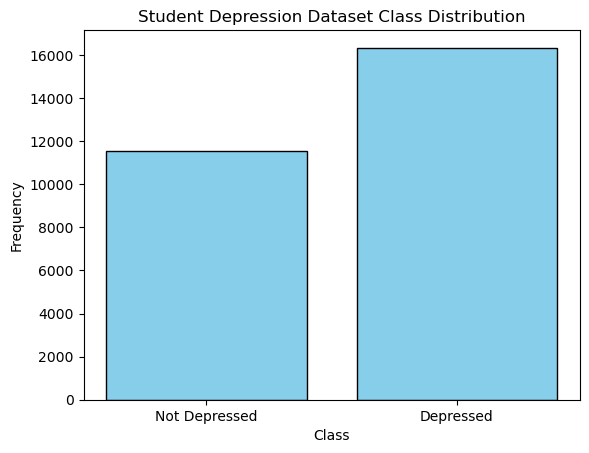

In [4]:
not_depressed_students = (depression_data["Depression"] == 0).sum()
depressed_students = (depression_data["Depression"] == 1).sum()

plt.bar(["Not Depressed", "Depressed"], [not_depressed_students, depressed_students], color="skyblue", edgecolor="black")
plt.title("Student Depression Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

As we can see, there is a **class imbalance** within our dataset. If we train our model with the imbalance, we will likely derive a model that favors the more frequent class, which will introduce unnecessary bias into our predictions. In order to solve this, we must manually pick the training data so that the training set's class distribution is balanced and sufficiently large. The remaining data will be separated among the validation set and the evaluation set.

## **Converting to Numeric Data Type**

Before we split the training, validation, and testing data, we must first convert non-numeric features to numeric features. As of now, we have the following non-numeric features in our dataset:

- `Sleep Duration`: The typical duration that the student sleeps at night.
    * `0`: 5-6 Hours
    * `1`: 7-8 Hours
    * `2`: Less than 5 hours
    * `3`: More than 8 hours
    * `4`: Others
      
- `Dietary Habits`: The quality of the student's diet and nutrition.
    * `0`: Healthy
    * `1`: Moderate
    * `2`: Others
    * `3`: Unhealthy

- `Have you ever had suicidal thoughts ?`: Indicates whether or not the student has had or is currently having suicidal thoughts.
    * `0`: No
    * `1`: Yes

- `Family History of Mental Illness`: Indicates whether or not the student's family has a history of mental illness.
    * `0`: No
    * `1`: Yes

Let us start by manipulating the non-numeric features to represent features numerically.

In [5]:
sleep_durations = dict({
    '5-6 hours': 0,
    '7-8 hours': 1,
    'Less than 5 hours': 2,
    'More than 8 hours': 3,
    'Others': 4
})

dietary_habits = dict({
    'Healthy': 0,
    'Moderate': 1,
    'Others': 2,
    'Unhealthy': 3
})

binary_values = dict({
    'No': 0,
    'Yes': 1
})

depression_data["Sleep Duration"] = depression_data["Sleep Duration"].map(sleep_durations)
depression_data["Dietary Habits"] = depression_data["Dietary Habits"].map(dietary_habits)
depression_data["Have you ever had suicidal thoughts ?"] = depression_data["Have you ever had suicidal thoughts ?"].map(binary_values)
depression_data["Family History of Mental Illness"] = depression_data["Family History of Mental Illness"].map(binary_values)

print(depression_data.dtypes)

Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                             int64
Dietary Habits                             int64
Have you ever had suicidal thoughts ?      int64
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness           int64
Depression                                 int64
dtype: object


Now that we have converted all features to be numeric, we can continue with splitting our dataset for training, validation, and testing.

## **Extracting the Training, Validation, and Evaluation Sets**

### Splitting the Positive and Negative Observations

Let us start by splitting the observations of depressed students from the observations of non-depressed students. This will later allow us to pick out the individual data points more easily later on. For clarity, we will be referring to observations of students diagnosed with depression as **positive observations**, and we will be referring to observations of students not diagnosed with depression as **negative observations**. We will split them through masking.

In [6]:
mask_negative = depression_data["Depression"] == 0
mask_positive = depression_data["Depression"] == 1

positive_observations = np.array(depression_data[mask_positive])
negative_observations = np.array(depression_data[mask_negative])

print("Number of Positive Observations:", len(positive_observations))
print("Number of Negative Observations:", len(negative_observations))
print("Number of Total Observations:", len(depression_data))

Number of Positive Observations: 16335
Number of Negative Observations: 11563
Number of Total Observations: 27898


### Splitting the Training and Testing Set

As we can see from the `print` statements above and from our earlier histogram, there are more positive observations than negative observations in the dataset. We will be aiming for the following split:

- **70%** Training
- **10%** Validation
- **20%** Evaluation

This means that we will have $0.7 * 27898 ≈ 19530$ training observations, with $\frac{19530}{2} = 9765$ positive and negative observations each. After that, we can use the `train_test_split()` function from `sklearn` to split the validation and evaluation data from the testing set.

In [7]:
training_positive_observations = positive_observations[0:9765]
training_negative_observations = negative_observations[0:9765]
testing_positive_observations = positive_observations[9765:len(positive_observations)]
testing_negative_observations = negative_observations[9765:len(negative_observations)]

training_set = np.concatenate((training_positive_observations, training_negative_observations), axis=0)
testing_set = np.concatenate((testing_positive_observations, testing_negative_observations), axis=0)

np.random.shuffle(training_set)
np.random.shuffle(testing_set)

print("Size of Training Set:", len(training_set))
print("Size of Testing Set:", len(testing_set))

Size of Training Set: 19530
Size of Testing Set: 8368


Now, let us visualize the distribution of the positive observations and negative observations in the training set and let us verify that the distribution is uniform.

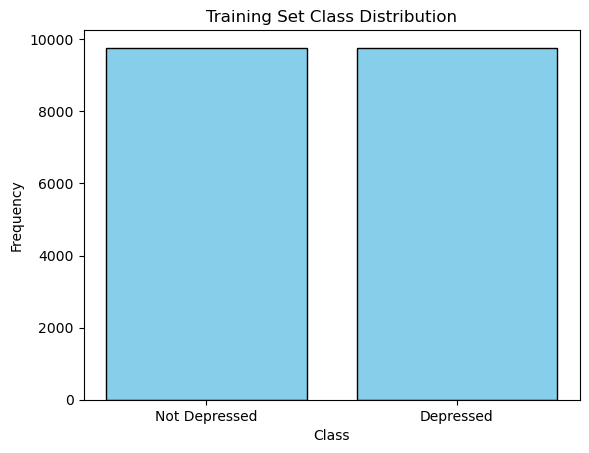

In [8]:
not_depressed_students = (training_set[:, 11] == 0).sum()
depressed_students = (training_set[:, 11] == 1).sum()

plt.bar(["Not Depressed", "Depressed"], [not_depressed_students, depressed_students], color="skyblue", edgecolor="black")
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

Let us now split the input features and the labels in the training set.

In [9]:
X_train = training_set[:, 0:11]
y_train = training_set[:, 11]

### Extracting the Validation and Evaluation Sets

We can use the `sklearn.model_selection.train_test_split()` to split the validation and evaluation sets from within the testing set. Since the validation set and the evaluation set make up 10% and 20% of the original dataset, respectively, they make up $\frac{1}{3}$ of the testing set and $\frac{2}{3}$ of the testing set respectively as well. One other advantage of the `train_test_split()` function is that it conserves the original class distribution of the input dataset before splitting. This means that the validation and evaluation sets will have similar class distributions to that of the entire testing set.

In [10]:
X_test = testing_set[:, 0:11]
y_test = testing_set[:, 11]

X_validation, X_evaluation, y_validation, y_evaluation = train_test_split(
    X_test, y_test,
    test_size=(2/3),
    random_state=42,
    shuffle=True
)

### Visualizing the Class Distributions of the Validation and Evaluation Sets

Let us start by visualizing the class distribution of the testing set.

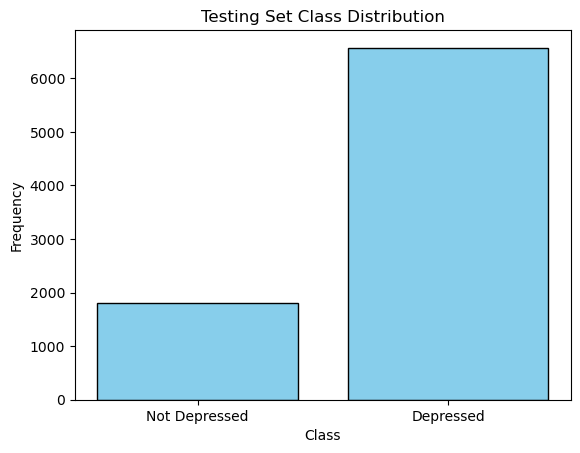

In [11]:
not_depressed_students = (y_test == 0).sum()
depressed_students = (y_test == 1).sum()

plt.bar(["Not Depressed", "Depressed"], [not_depressed_students, depressed_students], color="skyblue", edgecolor="black")
plt.title("Testing Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

Now, let us visualize the class distribution of the validation set.

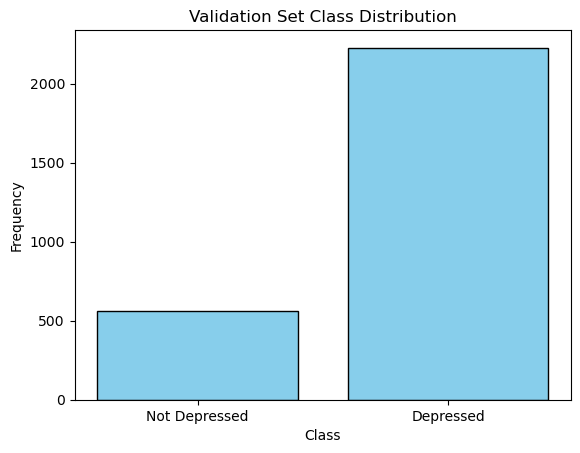

In [12]:
not_depressed_students = (y_validation == 0).sum()
depressed_students = (y_validation == 1).sum()

plt.bar(["Not Depressed", "Depressed"], [not_depressed_students, depressed_students], color="skyblue", edgecolor="black")
plt.title("Validation Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

Finally, let us visualize the class distribution of the evaluation set.

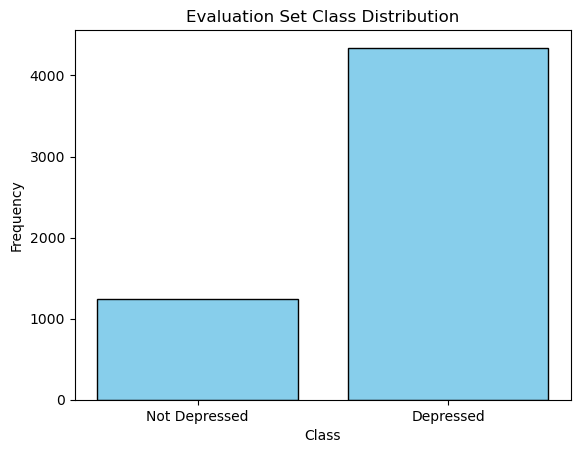

In [13]:
not_depressed_students = (y_evaluation == 0).sum()
depressed_students = (y_evaluation == 1).sum()

plt.bar(["Not Depressed", "Depressed"], [not_depressed_students, depressed_students], color="skyblue", edgecolor="black")
plt.title("Evaluation Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

Notice that the distributions all look similar, and that each set is guaranteed to have both positive and negative observations. Since the model will not be learning from neither the validation set nor the evaluation set, we do not have to ensure that the class distributions of the two sets are uniform.

## **Principal Component Analysis (PCA)**

### Computing the Mean Feature Vector

The first thing we will do for our Principal Component Analysis is compute the **Mean Feature Vector**. To do this, we will take the mean of each feature in the training set and create a new vector with these mean values.

In [14]:
mean_vector = X_train.mean(axis=0)
print("Dimensionality of Mean Vector:", mean_vector.shape)

Dimensionality of Mean Vector: (11,)


### Subtracting the Mean Vector From All Training Vectors

Next, we will center the training observations at the mean vector, meaning that we will simply subtract the mean vector from each training vector.

In [15]:
X_train_mean_centered = X_train - mean_vector
print("Dimensionality of Mean-Centered X:", X_train_mean_centered.shape)

Dimensionality of Mean-Centered X: (19530, 11)


### Computing the Covariance Matrix

Now that we jave mean-centered the training features, we can compute the covariance matrix $C$. The formula for computing the covariance matrix is: $C=\hat{X}^{T}\hat{X}$, where $\hat{X}$ represents the mean-centered training features in the form of a matrix where each row represents a single observation.

In [16]:
X = C = np.transpose(X_train_mean_centered) @ X_train_mean_centered
print("Dimensionality of C:", C.shape)

Dimensionality of C: (11, 11)


### Computing the Eigenvectors and Eigenvalues

In order to calculate the eigenvalues and eigenvectors of $C$, we will simply be leveraging the `numpy.linalg.eigh()` built-in function, which returns the eigenvalues and eigenvectors for a given input matrix represented as a `numpy` array, which would be $C$ in our case.

In [17]:
# lambdas - Eigenvalues
# loadings - Eigenvectors
lambdas, loadings = np.linalg.eigh(C)
print("Dimensionality of Loadings:", loadings.shape)

Dimensionality of Loadings: (11, 11)


### Representing 95% Maximum Variance

We will now calculate the number of principal components we need to represent at least 95% of the maximum variance. In order to do that, we must first sort the eigenvalues from greatest to least, so that we can later use a greedy algorithm to determine the subset of eigenvalues that represent at least 95% of the maximum variance.

In [18]:
loadings_transpose = np.transpose(loadings)

sort_indices = np.argsort(lambdas)[::-1]
lambdas = lambdas[sort_indices]
loadings_transpose = loadings_transpose[sort_indices]

loadings = np.transpose(loadings_transpose)

Now that we have sorted the eigenvalues in descending order, we can calculate the number of principal components needed by iterating over the sorted eigenvalues until the total of the visited eigenvalues is at least 95% of the total of all of the eigenvalues.

In [19]:
total = np.sum(lambdas)
current_total = 0
current_index = 0

while (current_total / total) < 0.95:
    current_total += lambdas[current_index]
    current_index += 1

lambdas_subset = lambdas[0:(current_index + 1)]
loadings_subset = loadings[:, 0:(current_index + 1)]
print("Number of Principal Components For 95% of Total Variance:", (current_index + 1))

Number of Principal Components For 95% of Total Variance: 8


### Visualizing the Principal Components of the Three Highest Eigenvalues

Now, let us visualize the principal components from the three highest eigenvalues. A principal component is a mean-centered vector multiplied by the corresponding eigenvectors of the three highest eigenvalues. These eigenvectors must be represented by a matrix where each column represents a single eigenvector.

In [20]:
lambdas_visualize = lambdas[0:3]
loadings_visualize = loadings[:, 0:3]
principal_components_visualize = X_train_mean_centered @ loadings_visualize

print("Dimensionality of Principal Components to Visualize:", principal_components_visualize.shape)

Dimensionality of Principal Components to Visualize: (19530, 3)


After deriving the principal components from each training data point, we can visualize the points in a 3D plot to see if we can find any cluster patterns between the positive and negative observations.

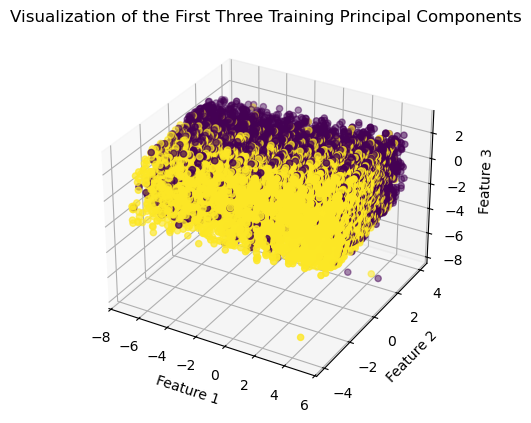

In [21]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    principal_components_visualize[:, 0],
    principal_components_visualize[:, 1],
    principal_components_visualize[:, 2],
    c=y_train
)

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
plt.title("Visualization of the First Three Training Principal Components")
plt.show()

As we can see from the plot above, there is a subtle level of clustering between the positive observations and negative observations, even though the clusters are not easily separable. However, since we need eight principal components to represent at least 95% of the total variance, we expect to see some inseparability when visualizing only three principal components.

### Deriving the Principal Components For Each Set

We can now derive the principal components for the training, validation, and evaluation sets. We will simply center each observation in the sets at the mean vector derived earlier, then we can multiply these mean-centered matrices with the matrix of the eigenvectors of the eight highest eigenvalues.

In [22]:
principal_components_train = X_train_mean_centered @ loadings_subset
principal_components_validation = (X_validation - mean_vector) @ loadings_subset
principal_components_evaluation = (X_evaluation - mean_vector) @ loadings_subset

print("Dimensionality of Training Matrix:", principal_components_train.shape)
print("Dimensionality of Validation Matrix:", principal_components_validation.shape)
print("Dimensionality of Evaluation Matrix:", principal_components_evaluation.shape)

Dimensionality of Training Matrix: (19530, 8)
Dimensionality of Validation Matrix: (2789, 8)
Dimensionality of Evaluation Matrix: (5579, 8)


## **Deep Learning with Principal Components**

### Building the Neural Network

Now that we have our principal components, we can build, train, and test our neural network, tweaking its architecture and hyper-parameters along the way to minimize the loss and maximize the accuracy of the model. We will start with setting up the architecture of the network. The following code segment creates a class that represents a `PyTorch` neural network. Since we will be representing an observation using eight principal components as the features, the network has 8 neurons in the input layer. Furthermore, since each student is either classified as having depression or not having depression, there are two neurons in the output layer. For the hidden layers, each hidden layer has one less neuron than the previous layer, meaning that if the input layer has eight neurons, the first hidden layer has seven, and the second hidden layer has six, and so on until we get two output neurons. Each layer is activated by the ReLU activation function.

In [23]:
class PrincipalComponentNN(nn.Module):
    def __init__(self):
        super(PrincipalComponentNN, self).__init__()

        # Linear Layers
        self.layer1 = nn.Linear(8, 7)
        self.layer2 = nn.Linear(7, 6)
        self.layer3 = nn.Linear(6, 5)
        self.layer4 = nn.Linear(5, 4)
        self.layer5 = nn.Linear(4, 3)
        self.layer6 = nn.Linear(3, 2)

        # Activation Functions
        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

        # Dropout Layers
        self.dropout1 = nn.Dropout(p=0.4)
        self.dropout2 = nn.Dropout(p=0.3)

        # Batch Normalization Layers
        self.bn1 = nn.BatchNorm1d(7)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.layer3(x)
        x = self.relu(x)
        x = self.layer4(x)
        x = self.relu(x)
        x = self.layer5(x)
        x = self.relu(x)
        x = self.layer6(x)
        return x

### Initializing the Hyper-Parameters

Before we move on and initialize our hyper-parameters for training the network, we must first convert our training inputs and labels into tensors. Tensors are a generalization of multi-dimensional data types and allow `PyTorch` to more efficiently perform forward propagation, loss computations, backward propagation, and gradient descent, allowing for higher training speed.

In [24]:
training_input_tensor = torch.tensor(principal_components_train, dtype=torch.float)
training_label_tensor = torch.tensor(y_train, dtype=torch.long)

validation_input_tensor = torch.tensor(principal_components_validation, dtype=torch.float)
validation_label_tensor = torch.tensor(y_validation, dtype=torch.long)

Now, we can initialize the model and its hyper-parameters. For the purpose of this project, we will be using a learning rate of $10^{-3}$, setting the loss function to be the **Cross-Entropy** loss function, and initializing the `Adam` optimizer. Furthermore, we will be training the model over 15 iterations or **epochs**, or until the validation accuracy stops improving.

In [25]:
model = PrincipalComponentNN()
learning_rate = 1e-3
loss_criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
epochs = 15

### K-Fold Cross Validation

One other thing we have to decide is the number of steps we will take towards the local minimum when we train our model. The two common ways of doing this are using **Stochastic Gradient Descent** and through **Batch Gradient Descent**. Stochastic Gradient Descent means taking one step for each training data point that the model learns from. However, this may cause the model to memorize the noise that is presented in a singular observation, which could deter the model's ability to generalize from the training data over time. Batch Gradient Descent, on the other hand, means taking one step towards the local minimum after processing the entire training set in a singular iteration. This would mean that we have to tune the number of epochs to a specific level such that it is neither too low nor too high. A low number of epochs will result in the model underfitting the data, while a high number of epochs will result in the model memorizing and overfitting the training data.

The middle ground between the two methods is called the **Mini-Batch Gradient Descent**, which is what we will be using for training our model. Using a technique called **K-Fold Cross Validation**, we will be splitting the training set into $k$ batches at each iteration, and we will be taking a step towards the local minimum after processing one mini-batch. This allows the model to recognize patterns across the data in one mini-batch, while ignoring noise. With proper tuning of the learning rate, the model can then converge closer to the local minimum.

In [26]:
k = 30
kf = KFold(n_splits=k, shuffle=True, random_state=42)

Luckily, the `sklearn` module has implemented the `sklearn.model_selection.KFold` object, which will allow us to efficiently split the training set into different, class-balanced batches at each training epoch. For the purpose of this project, we will be using $k=30$ batches at each epoch.

### Training the Neural Network

Now that we have our model and hyper-parameters initialized, we can start training the model. One other thing we can implement is called **Early Stopping**. This allows the training to terminate once the validation loss curve is found to have reached a minimum. This is determined by initializing a **Tolerance** value $T$ and a **Patience** value $P$ such that if the validation loss does not improve by more than $T$ for $P$ epochs, then the training terminates. This allows us to signal if the model's validation accuracy is reaching a plateau or if there are any other limitations created by the model's architecture or the setting of the hyper-parameters.

In [27]:
training_loss_values = []
validation_loss_values = []
training_accuracy_values = []
validation_accuracy_values = []
current_patience_count = 0
tolerance = 1e-2
early_stopping_patience = 5
last_epoch = epochs

As indicated previously, we will be training our model over **15** epochs by splitting the entire training set into $k=30$ batches in each epoch. Therefore, the model will be taking $30 * 15 = 450$ steps towards the local minimum through gradient descent, assuming early stopping does not terminate the training early. It is also important to note that we will be validating the model once after each epoch, but the model **will not learn** from the validation set. This set will only be used to monitor the model's progress on unlearned data over the training epochs.

In [28]:
for epoch in range(epochs):
    print("-> TRAINING EPOCH " + str(epoch + 1) + " OF " + str(epochs))

    current_batch = 1
    training_loss = 0
    training_accuracy = 0
    
    for train_index, test_index in kf.split(training_input_tensor):
        all_indices = train_index.tolist() + test_index.tolist()
        X, y = training_input_tensor[all_indices], training_label_tensor[all_indices]

        model.train()

        optimizer.zero_grad()
        predictions = model(X)
        loss = loss_criterion(predictions, y)
        training_loss += loss.item()
        loss.backward()
        optimizer.step()

        index = 0
        cnt = 0

        for vec in predictions:
            if torch.argmax(vec).item() == y[index]:
                cnt += 1
            index += 1

        training_accuracy += (cnt / len(y))

        current_batch += 1

    training_loss /= k
    training_accuracy /= k

    training_loss_values.append(training_loss)
    training_accuracy_values.append(training_accuracy)

    model.eval()

    predictions = model(validation_input_tensor)
    loss = loss_criterion(predictions, validation_label_tensor)

    cnt = 0
    index = 0
    
    for vec in predictions:
        if torch.argmax(vec).item() == y_validation[index]:
            cnt += 1
        index += 1

    if (len(validation_loss_values) > 0) and (loss.item() >= (validation_loss_values[len(validation_loss_values) - 1] - tolerance)):
        current_patience_count += 1
    else:
        current_patience_count = 0

    if current_patience_count == early_stopping_patience:
        print("\nEARLY STOPPING: Validation Loss Has Not Improved For " + str(early_stopping_patience) + " epochs!")
        last_epoch = epoch + 1
        validation_loss_values.append(loss.item())
        validation_accuracy_values.append(cnt / len(y_validation))
        break

    validation_loss_values.append(loss.item())
    validation_accuracy_values.append(cnt / len(y_validation))

-> TRAINING EPOCH 1 OF 15
-> TRAINING EPOCH 2 OF 15
-> TRAINING EPOCH 3 OF 15
-> TRAINING EPOCH 4 OF 15
-> TRAINING EPOCH 5 OF 15
-> TRAINING EPOCH 6 OF 15
-> TRAINING EPOCH 7 OF 15
-> TRAINING EPOCH 8 OF 15
-> TRAINING EPOCH 9 OF 15
-> TRAINING EPOCH 10 OF 15
-> TRAINING EPOCH 11 OF 15
-> TRAINING EPOCH 12 OF 15

EARLY STOPPING: Validation Loss Has Not Improved For 5 epochs!


### Visualizing the Loss and Accuracy Curves

One of the best methods to diagnose any limitations in the model's training is through visualizing the training and validation curves over the training epochs. Specifically, plotting the training loss and accuracy, and the validation loss and accuracy will allow us to better visualize the progress of the model and think about how to improve the training procedure.

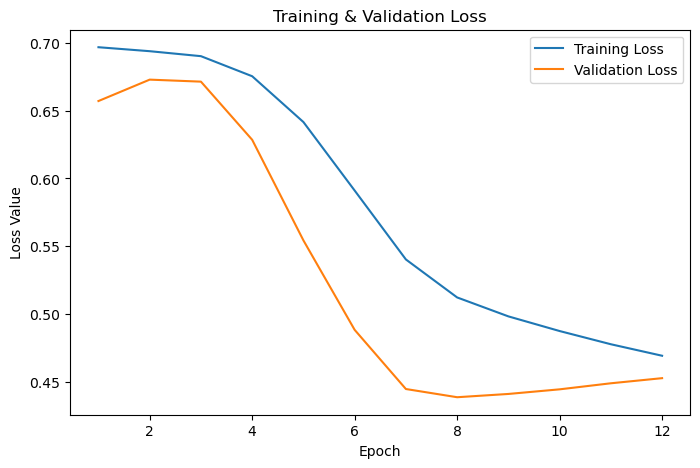

In [34]:
epochs = list(range(1, last_epoch + 1))

plt.figure(figsize=(8, 5))
plt.plot(epochs, training_loss_values, label="Training Loss")
plt.plot(epochs, validation_loss_values, label="Validation Loss")
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss Value")
plt.legend()
plt.show()

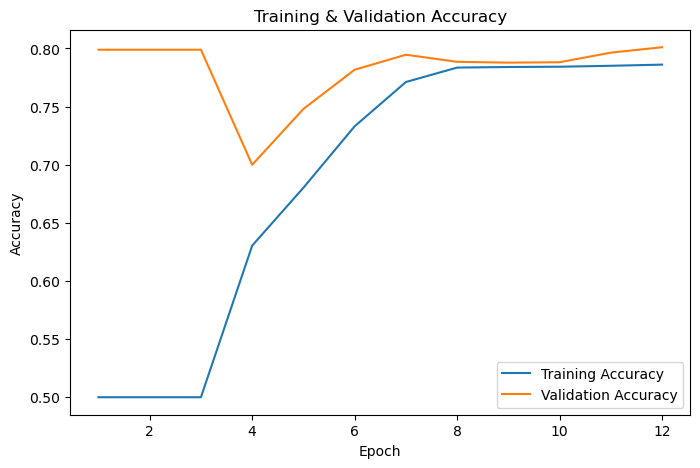

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, training_accuracy_values, label="Training Accuracy")
plt.plot(epochs, validation_accuracy_values, label="Validation Accuracy")
plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

As we can see from the plots above, the training and validation loss decreases as the training epochs progress. However, we can see that although training accuracy increases over the epochs, the validation accuracy reaches a plateau at a very early epoch, indicating possible underfitting as the model struggles to recognize distinct patterns after the fourth epoch.

### Evaluating the model

Even though examining the accuracy of the model on unseen data is an important part of model evaluation, we must also examine the **Precision** and **Recall** of the data as well the distribution of the class predictions during the evaluation. This data can allow us to understand whether or not the model has recognized patterns to distinguish the two classes.

In [36]:
testing_inputs = principal_components_evaluation
testing_labels = y_evaluation

true_positives = 0
true_negatives = 0
false_positives = 0
false_negatives = 0

for i in range(len(testing_inputs)):
    X = torch.tensor([testing_inputs[i]], dtype=torch.float)
    y = torch.tensor([testing_labels[i]], dtype=torch.long)

    prediction = model(X)
    
    if testing_labels[i]:
        if np.argmax(prediction.detach().numpy()[0]):
            true_positives += 1
        else:
            false_negatives += 1
    else:
        if np.argmax(prediction.detach().numpy()[0]):
            false_positives += 1
        else:
            true_negatives += 1

print("Precision:", true_positives / (true_positives + false_positives))
print("Recall:", true_positives / (true_positives + false_negatives))
print("Evaluation Accuracy:", (true_positives + true_negatives) / len(testing_labels))

Precision: 0.9237574811345303
Recall: 0.81759557807462
Evaluation Accuracy: 0.8055207026348808


As we can see from the statements above, the model has a precision of approximately 0.924, a recall of approximately 0.818, and an evaluation accuracy of approximately 0.806. This means that of all the positive predictions, approximately **92.4%** were correct, and out of all of the positive ground-truth observations, approximately **81.8%** were classified correctly, and lastly, of all of the observations in the evaluation set, approximately **80.6%** were classified correctly. This is a good sign, indicating that our model has in fact learned some of the key patterns to distinguish between the classes. Let us also visualize the distribution of the model's predictions on the evaluation set.

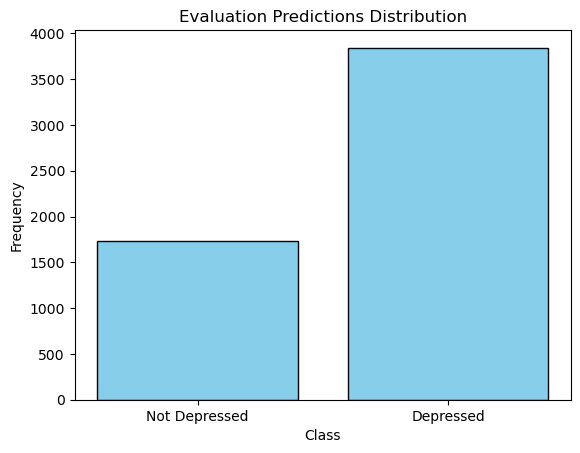

In [37]:
not_depressed_students = true_negatives + false_negatives
depressed_students = true_positives + false_positives

plt.bar(["Not Depressed", "Depressed"], [not_depressed_students, depressed_students], color="skyblue", edgecolor="black")
plt.title("Evaluation Predictions Distribution")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

### Saving the Model's Parameters [Optional]

Now that we have a good model, we can save its parameters locally using the following code. It is important to note that although this code saves the model parameters, **it does not save the model's architecture, which must be stored separately as well.**

In [38]:
torch.save(model.state_dict(), "student_depression_model_parameters.pth")

## **Discussion**

### Calculating the Probability of Depression

Now that we have a working model that can classify whether or not a student is depressed based on the input data of the student relatively well, we must understand that the model is not intended to substitute a Psychologist to conduct evaluations and diagnose patients. It is merely a mathematical model that uses numerical data to return values indicating the degree of likelihood that an observation belongs to certain classes. In our case, the model returns values or **logits** to indicate if an observation represents a depressed student or not. If the logit indicating that the student is depressed is higher, then we can say that the model is inclined towards classifying the student as depressed. Otherwise, we can say that the model is inclined towards classifying the student as not depressed. Furthermore, we must recognize that **THE MODEL IS NOT ALWAYS RIGHT**; though it has a relatively high accuracy, it is still not a 100% accurate. But how can we calculate the probability that an observation represents a depressed student given the output logits of the observation from the model and the model's accuracy?

1. **Softmax Activation:** We will get two output logits; one for the student belonging to the "depressed" class and one for the student belonging the the "not depressed" class. We must convert these logits into normalized probability values using the Softmax Function, where $z_{i}$ represents the logit value of the $i^{th}$ class and $N$ represents the total number of classes:

   $$
   \text{softmax}(z_{i})=\frac{e^{z_i}}{\sum_{j=0}^{N}z_{j}}
   $$
   
3. **Chain Rule**: Suppose we denote the probability of an observation representing a depressed student as $P(D)$. We can also represent the event that the model classifies the observation correctly as $R$. Then, $P(D|R)$ denotes the probability that the observation represents a depressed student **given that** the model classifies the observation correctly, which is equal to the normalized probability of the student being depressed derived from the previous step. Furthermore, the probability of the model classifying correctly is equal to the accuracy of the model denoted by $\alpha$, meaning that:

   $$
   P(D)=P(D|R)*\alpha
   $$

## **Conclusion**

To answer our original research question for this project, we were able to train a model to classify a student being depressed with approximately **80% accuracy**. That being said, we cannot completely rely on models to diagnose patients, but we can use their assistance to gain an understanding of how likely a student is to be diagnosed with depression. Further evaluation and counseling is required to further diagnose and understand a patient's mental state to come up with a proper treatment plan.